# IT3212 Assignment 2 - Blob detection (15 points)

We implement a multiscale Laplacian-of-Gaussian (LoG) detector, apply it to every image in the
vehicle-type dataset, visualize detections, report their positions and sizes, and investigate parameters.
The algorithm finds locally contrasting image regions, **not semantic vehicle instances**.

Run all cells from a fresh Python kernel with the repository requirements installed. Outputs are saved
under `figures/assignment2/blob_detection/`; numerical results go to the gitignored
`results/assignment2/blob_detection/`. The manifest selects display examples only; it does not limit the analysis.
Baseline overlays for every image are saved under `results/assignment2/blob_detection/overlays/`.

The numbered sections below match the four blob-detection subquestions in the assignment PDF:
1. Apply the algorithm to a provided dataset.
2. Visualize detections using circles or boxes.
3. Calculate and display counts, sizes, and positions.
4. Evaluate the effects of algorithm parameters.

In [8]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
from PIL import Image, ImageOps, ImageDraw
from concurrent.futures import ThreadPoolExecutor
import os
import time
import errno
import tempfile
from io import BytesIO
from scipy.ndimage import gaussian_filter, gaussian_laplace, maximum_filter
from IPython.display import display, Markdown
import scipy
import PIL

REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / "AGENTS.md").is_file() and (p / "notebooks").is_dir()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Run from within the IT3212 repository.")
DATA_DIR = REPO_ROOT / "data" / "vehicle-type-detection"
FIGURE_DIR = REPO_ROOT / "figures" / "assignment2" / "blob_detection"
RESULT_DIR = REPO_ROOT / "results" / "assignment2" / "blob_detection"
if not DATA_DIR.is_dir():
    raise FileNotFoundError(DATA_DIR)
OVERLAY_DIR = RESULT_DIR / "overlays"
WORKERS = min(4, os.cpu_count() or 1)
for directory in [FIGURE_DIR, RESULT_DIR, OVERLAY_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
print(f"Python {sys.version.split()[0]}, NumPy {np.__version__}, SciPy {scipy.__version__}, Pillow {PIL.__version__}")

def save_png(render_png, destination):
    """Render fully, then replace the output; retry temporary Windows file-access errors."""
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    # Rendering errors propagate before touching an existing result file.
    with BytesIO() as buffer:
        render_png(buffer)
        png_bytes = buffer.getvalue()
    descriptor, temporary_name = tempfile.mkstemp(
        prefix=f".{destination.stem}_", suffix=".tmp", dir=destination.parent)
    temporary_path = Path(temporary_name)
    try:
        with os.fdopen(descriptor, "wb") as stream:
            stream.write(png_bytes)
        # Same-directory replacement avoids truncating an existing image during rendering.
        for attempt in range(4):
            try:
                os.replace(temporary_path, destination)
                break
            except OSError as error:
                temporary_access_error = (
                    error.errno in {errno.EACCES, errno.EBUSY, errno.EINVAL, errno.EPERM}
                    or getattr(error, "winerror", None) in {5, 32, 33}
                )
                if not temporary_access_error:
                    raise
                if attempt == 3:
                    raise OSError(
                        error.errno,
                        "Could not replace the output PNG. If open in another program, close it "
                        "and rerun this cell. Also check folder write access. "
                        "The previous image was preserved.", str(destination)
                    ) from error
                time.sleep(0.25 * 2**attempt)
    finally:
        temporary_path.unlink(missing_ok=True)


def save_figure(figure, destination, **kwargs):
    save_png(lambda stream: figure.savefig(stream, format="png", **kwargs), destination)


Python 3.13.7, NumPy 2.5.2, SciPy 1.18.1, Pillow 12.3.0


## 1. Apply blob detection to the dataset

**Assignment point 1:** Apply the blob detection algorithm to one of the provided Blackboard image datasets.

### Full dataset and display examples

The supplied dataset contains five vehicle-type folders. Its original source/Blackboard attribution
must still be recorded before submission. **Every image discovered below is processed** by the baseline
and all seven parameter settings. No image is excluded just because it is absent from the display manifest.

`detection_images.json` selects ten examples for compact figures only. Dataset-wide statistics and
per-image marked outputs cover the full dataset. Vehicle-type labels do not annotate blobs, so counts
cannot be interpreted as vehicle counts or used to calculate detection precision/recall.

In [9]:
extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
image_ids = sorted(p.relative_to(DATA_DIR).as_posix() for p in DATA_DIR.rglob("*")
                   if p.is_file() and p.suffix.lower() in extensions)
if not image_ids:
    raise ValueError("No images found in the dataset.")
assert len(image_ids) == len(set(image_ids))
assert len({str(Path(i).with_suffix(".png")) for i in image_ids}) == len(image_ids), "Overlay filenames collide."
inventory = pd.Series([Path(i).parts[0] for i in image_ids]).value_counts().sort_index().rename_axis("class").reset_index(name="images")
display(inventory)
print(f"Analysis covers all {len(image_ids)} images; workers: {WORKERS}.")
manifest_path = REPO_ROOT / "notebooks" / "assignment2" / "detection_images.json"
display_ids = json.loads(manifest_path.read_text(encoding="utf-8"))
assert display_ids and len(display_ids) == len(set(display_ids))
assert set(display_ids).issubset(image_ids), "Display examples must exist in the dataset."
print(f"Figures in the notebook show {len(display_ids)} fixed examples.")

,class,images
0,hatchback,181
1,motorcycle,122
2,pickup,478
3,sedan,400
4,suv,129


Analysis covers all 1310 images; workers: 4.
Figures in the notebook show 10 fixed examples.


### Image preparation

Apply EXIF orientation, convert to RGB for display and grayscale for detection, and divide grayscale
intensities by 255 to obtain `[0, 1]`. Limit the longest side to 512 pixels with aspect ratio preserved;
do not enlarge small images. This bounds computation without forcing different shapes into a square.
The table records the actual dimensions and resize factors. Pixels do not have a common physical size
across these photographs, so equal radii do not imply equal physical objects.

We retain intensity contrast without histogram equalization. Gaussian smoothing is already part of LoG;
additional smoothing is zero in the baseline and tested separately. Coordinates use the top-left origin:
`x` increases to the right and `y` downwards. All plotted circles and primary measurements refer to the
processed image. Original-coordinate columns refer to the EXIF-oriented image.

,image,original_width,original_height,width,height,scale_x,scale_y
0,hatchback/PIC_0.jpg,136,173,136,173,1.000000,1.000000
1,hatchback/PIC_1.jpg,597,420,512,360,0.857621,0.857143
2,motorcycle/PIC_0.jpg,301,514,300,512,0.996678,0.996109
3,motorcycle/PIC_10.jpg,92,162,92,162,1.000000,1.000000
4,pickup/PIC_0.jpg,313,241,313,241,1.000000,1.000000
5,pickup/PIC_1.jpg,353,224,353,224,1.000000,1.000000
6,sedan/PIC_0.jpg,196,155,196,155,1.000000,1.000000
7,sedan/PIC_1.jpg,552,351,512,326,0.927536,0.928775
8,suv/PIC_0.jpg,509,338,509,338,1.000000,1.000000
9,suv/PIC_1.jpg,309,249,309,249,1.000000,1.000000


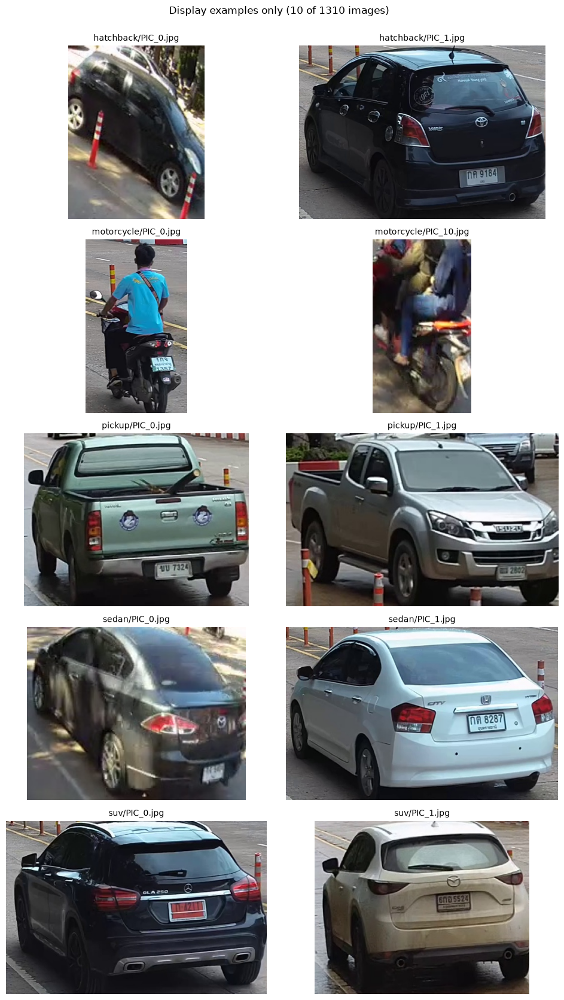

In [10]:
MAX_SIDE = 512

def load_image(image_id):
    with Image.open(DATA_DIR / image_id) as source:
        rgb_image = ImageOps.exif_transpose(source).convert("RGB")
    original_width, original_height = rgb_image.size
    factor = min(1.0, MAX_SIDE / max(rgb_image.size))
    size = (max(1, round(original_width * factor)), max(1, round(original_height * factor)))
    if size != rgb_image.size:
        rgb_image = rgb_image.resize(size, Image.Resampling.LANCZOS)
    gray = np.asarray(rgb_image.convert("L"), dtype=np.float64) / 255.0
    assert gray.ndim == 2 and np.isfinite(gray).all() and 0 <= gray.min() <= gray.max() <= 1
    return dict(rgb=np.asarray(rgb_image), gray=gray,
                original_width=original_width, original_height=original_height,
                width=size[0], height=size[1],
                scale_x=size[0] / original_width, scale_y=size[1] / original_height)

# Retain image arrays only for display examples; load the remaining images one at a time per worker.
records = {image_id: load_image(image_id) for image_id in display_ids}
display(pd.DataFrame([dict(image=i, **{k: v for k, v in r.items() if k not in {"rgb", "gray"}})
                      for i, r in records.items()]))
n_rows = (len(display_ids) + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(10, 3.4 * n_rows), squeeze=False)
for ax, (image_id, record) in zip(axes.flat, records.items()):
    ax.imshow(record["rgb"])
    ax.set_title(image_id, fontsize=10)
    ax.axis("off")
for ax in axes.flat[len(display_ids):]:
    ax.axis("off")
fig.suptitle(f"Display examples only ({len(display_ids)} of {len(image_ids)} images)")
fig.tight_layout(rect=(0, 0, 1, 0.98))
save_figure(fig, FIGURE_DIR / "01_original_images.png", dpi=140)
plt.show()
plt.close(fig)

### Algorithm: scale-normalized Laplacian of Gaussian

For each scale $\sigma$, calculate $R_\sigma=-\sigma^2\nabla^2(G_\sigma * I)$.
The implementation below uses SciPy for Gaussian derivatives and neighborhood maxima; scale selection,
polarity handling, thresholding, and suppression are implemented explicitly here.

1. Evaluate 12 logarithmically spaced scales between 4 and 16 pixels. The $\sigma^2$ factor compensates
   for attenuation at larger scales.
2. Find local maxima of $|R_\sigma|$ in a $3\times3\times3$ neighborhood of scale, row, and column.
   Positive signed responses indicate bright centers; negative responses indicate dark centers.
3. Require response magnitude above 0.15. This is a contrast-response threshold, not a probability.
4. Approximate each blob by a circle with radius $r=\sqrt{2}\sigma$. Exclude circles crossing the frame:
   their size is poorly constrained. This intentionally loses partially visible border blobs.
5. Sort candidates by response strength and suppress any circle whose intersection exceeds 50% of
   the smaller circle's area with an already retained circle. This suppression applies across polarities.

A preliminary run with minimum sigma 2 and threshold 0.05 produced thousands of small detections.
We raised these to 4 and 0.15 for more legible exploratory figures; this is sample-based parameter
selection, not independent validation. The same settings are applied to every image. They are a baseline for comparison, not an optimized
vehicle detector. Absolute LoG response can also peak on the sides of edges; visual inspection is needed.
The radius describes a filter scale, not a segmented object boundary, and $\pi r^2$ is an approximate
circle area, not the measured area of a vehicle.

In [11]:
def circle_overlap_fraction(a, b):
    """Intersection area divided by smaller circle area; circles are (y, x, radius)."""
    y1, x1, r1 = a
    y2, x2, r2 = b
    distance = np.hypot(y1 - y2, x1 - x2)
    if distance >= r1 + r2:
        return 0.0
    if distance <= abs(r1 - r2):
        return 1.0
    angle1 = np.arccos(np.clip((distance**2 + r1**2 - r2**2) / (2 * distance * r1), -1, 1))
    angle2 = np.arccos(np.clip((distance**2 + r2**2 - r1**2) / (2 * distance * r2), -1, 1))
    product = (-distance + r1 + r2) * (distance + r1 - r2) * (distance - r1 + r2) * (distance + r1 + r2)
    area = r1**2 * angle1 + r2**2 * angle2 - 0.5 * np.sqrt(max(0.0, product))
    return area / (np.pi * min(r1, r2)**2)

def overlaps_any(circle, previous, threshold):
    """Vectorized circle-overlap calculation with the same smaller-area suppression rule."""
    if not previous:
        return False
    y, x, radius = circle
    prior = np.asarray(previous)
    distances = np.hypot(prior[:, 0] - y, prior[:, 1] - x)
    radii = prior[:, 2]
    intersect = distances < radius + radii
    if not intersect.any():
        return False
    distances, radii = distances[intersect], radii[intersect]
    contained = distances <= np.abs(radius - radii)
    if threshold < 1 and contained.any():
        return True
    distances, radii = distances[~contained], radii[~contained]
    if not len(distances):
        return False
    angle1 = np.arccos(np.clip((distances**2 + radius**2 - radii**2) / (2 * distances * radius), -1, 1))
    angle2 = np.arccos(np.clip((distances**2 + radii**2 - radius**2) / (2 * distances * radii), -1, 1))
    product = (-distances + radius + radii) * (distances + radius - radii) * (distances - radius + radii) * (distances + radius + radii)
    areas = radius**2 * angle1 + radii**2 * angle2 - 0.5 * np.sqrt(np.maximum(0.0, product))
    return bool((areas / (np.pi * np.minimum(radius, radii)**2) > threshold).any())

BLOB_COLUMNS = ["x_px", "y_px", "sigma_px", "radius_px", "diameter_px",
                "circle_area_px2", "response", "polarity"]

def detect_blobs(gray, min_sigma=4.0, max_sigma=16.0, num_sigma=12,
                 threshold=0.15, overlap=0.5, pre_smooth=0.0, response_cache=None):
    """Return bright and dark LoG blobs in processed-image coordinates."""
    gray = np.asarray(gray, dtype=np.float64)
    if gray.ndim != 2 or not np.isfinite(gray).all() or gray.min() < 0 or gray.max() > 1:
        raise ValueError("Expected a finite 2D grayscale image in [0, 1].")
    if not (0 < min_sigma < max_sigma and num_sigma >= 3 and threshold > 0
            and 0 <= overlap <= 1 and pre_smooth >= 0):
        raise ValueError("Invalid detector parameters.")
    # A cache belongs to one image only; threshold/overlap changes reuse its scale responses.
    key = (min_sigma, max_sigma, num_sigma, pre_smooth)
    if response_cache is not None and key in response_cache:
        sigmas, signed = response_cache[key]
    else:
        prepared = gaussian_filter(gray, pre_smooth, mode="reflect") if pre_smooth else gray
        sigmas = np.geomspace(min_sigma, max_sigma, num_sigma)
        signed = np.stack([-s**2 * gaussian_laplace(prepared, s, mode="reflect") for s in sigmas])
        if response_cache is not None:
            response_cache[key] = (sigmas, signed)
    strength = np.abs(signed)
    peaks = (strength == maximum_filter(strength, size=(3, 3, 3), mode="nearest")) & (strength > threshold)
    scale_indices, ys, xs = np.nonzero(peaks)
    scores = strength[scale_indices, ys, xs]
    kept_circles, rows = [], []
    height, width = gray.shape
    for index in np.argsort(-scores, kind="stable"):
        scale_index, y, x = scale_indices[index], ys[index], xs[index]
        sigma = sigmas[scale_index]
        radius = np.sqrt(2) * sigma
        if x - radius < 0 or y - radius < 0 or x + radius > width - 1 or y + radius > height - 1:
            continue
        circle = (float(y), float(x), radius)
        if overlaps_any(circle, kept_circles, overlap):
            continue
        kept_circles.append(circle)
        rows.append(dict(x_px=float(x), y_px=float(y), sigma_px=sigma, radius_px=radius,
                         diameter_px=2 * radius, circle_area_px2=np.pi * radius**2,
                         response=float(scores[index]),
                         polarity="bright" if signed[scale_index, y, x] > 0 else "dark"))
    return pd.DataFrame(rows, columns=BLOB_COLUMNS)

BASELINE = dict(min_sigma=4.0, max_sigma=16.0, num_sigma=12,
                threshold=0.15, overlap=0.5, pre_smooth=0.0)
display(pd.Series(BASELINE, name="baseline value"))

min_sigma      4.00
max_sigma     16.00
num_sigma     12.00
threshold      0.15
overlap        0.50
pre_smooth     0.00
Name: baseline value, dtype: float64

### Sanity check with known synthetic blobs

Two isolated Gaussian spots let us check center localization and scale selection without vehicle
annotations. A constant image should produce no detections. These checks validate basic behavior,
not performance on photographs.

In [12]:
yy, xx = np.mgrid[:128, :128]
synthetic = (0.5 + 0.4 * np.exp(-((xx - 35)**2 + (yy - 35)**2) / (2 * 5**2))
             - 0.4 * np.exp(-((xx - 90)**2 + (yy - 90)**2) / (2 * 8**2)))
check = detect_blobs(synthetic, **{**BASELINE, "threshold": 0.10})
for x, y, sigma, polarity in [(35, 35, 5, "bright"), (90, 90, 8, "dark")]:
    nearby = check[(np.hypot(check.x_px - x, check.y_px - y) <= 2) & (check.polarity == polarity)]
    assert len(nearby) == 1
    assert abs(nearby.iloc[0].sigma_px - sigma) / sigma < 0.25
assert detect_blobs(np.full((64, 64), 0.5), **BASELINE).empty
assert circle_overlap_fraction((0, 0, 2), (0, 0, 2)) == 1
assert circle_overlap_fraction((0, 0, 2), (10, 10, 2)) == 0
print("Passed: known centers and polarities, approximate scales, empty constant image, overlap extremes.")

Passed: known centers and polarities, approximate scales, empty constant image, overlap extremes.


In [13]:
def image_metadata(image_id, record):
    return dict(image=image_id, **{k: v for k, v in record.items() if k not in {"rgb", "gray"}})

baseline_results = {}
info_rows = []
started = time.perf_counter()

def baseline_for_image(image_id):
    record = records.get(image_id)
    if record is None:
        record = load_image(image_id)
    return image_id, detect_blobs(record["gray"], **BASELINE), image_metadata(image_id, record)

# map yields results in sorted input order; worker count does not change the detector settings.
with ThreadPoolExecutor(max_workers=WORKERS) as pool:
    for done, (image_id, blobs, metadata) in enumerate(pool.map(baseline_for_image, image_ids), start=1):
        baseline_results[image_id] = blobs
        info_rows.append(metadata)
        if done % 100 == 0 or done == len(image_ids):
            print(f"Baseline: {done}/{len(image_ids)} images ({time.perf_counter() - started:.1f} s)", flush=True)
image_info = pd.DataFrame(info_rows)
assert list(baseline_results) == image_ids
print(f"Baseline processed every image: {len(baseline_results)}.")

Baseline: 100/1310 images (2.9 s)
Baseline: 200/1310 images (5.3 s)
Baseline: 300/1310 images (8.1 s)
Baseline: 400/1310 images (10.1 s)
Baseline: 500/1310 images (12.4 s)
Baseline: 600/1310 images (14.6 s)
Baseline: 700/1310 images (17.0 s)
Baseline: 800/1310 images (19.3 s)
Baseline: 900/1310 images (21.6 s)
Baseline: 1000/1310 images (24.0 s)
Baseline: 1100/1310 images (26.9 s)
Baseline: 1200/1310 images (30.2 s)
Baseline: 1300/1310 images (33.4 s)
Baseline: 1310/1310 images (33.8 s)
Baseline processed every image: 1310.


## 2. Visualize the detected blobs

**Assignment point 2:** Visualize blobs on the original images, marking each with a circle or bounding box.

Yellow circles denote bright blobs and cyan circles dark blobs. IDs in the individual saved images
match the per-blob table in point 3. The inline figures show display examples at the processed resolution.
An overlay is also saved for **every dataset image** under `results/assignment2/blob_detection/overlays/`,
using the EXIF-oriented original resolution. Processed coordinates are mapped back before drawing;
slightly different x/y resize factors produce correspondingly scaled ellipses in original coordinates.

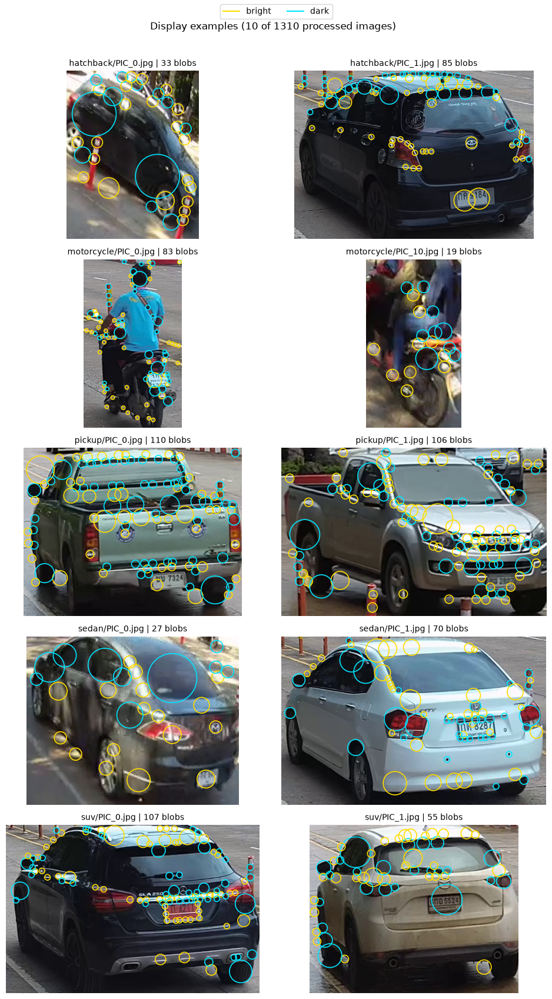

Saved 1310 original-resolution overlays to c:\Users\fredr\Documents\MIDT\IT3212\results\assignment2\blob_detection\overlays.


In [14]:
COLORS = {"bright": "#ffdc00", "dark": "#00e5ff"}

def draw_blobs(ax, record, blobs, title, annotate=False):
    ax.imshow(record["rgb"])
    for blob_id, row in enumerate(blobs.itertuples(index=False), start=1):
        color = COLORS[row.polarity]
        ax.add_patch(Circle((row.x_px, row.y_px), row.radius_px, fill=False, color=color, linewidth=1.2))
        if annotate:
            ax.text(row.x_px, row.y_px, str(blob_id), fontsize=6, color=color,
                    bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=0.3))
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-0.5, record["width"] - 0.5)
    ax.set_ylim(record["height"] - 0.5, -0.5)
    ax.axis("off")

fig, axes = plt.subplots(n_rows, 2, figsize=(10, 3.4 * n_rows), squeeze=False)
for ax, (image_id, record) in zip(axes.flat, records.items()):
    blobs = baseline_results[image_id]
    draw_blobs(ax, record, blobs, f"{image_id} | {len(blobs)} blobs")
for ax in axes.flat[len(display_ids):]:
    ax.axis("off")
fig.suptitle(f"Display examples ({len(display_ids)} of {len(image_ids)} processed images)")
fig.legend(handles=[Line2D([], [], color=color, label=label) for label, color in COLORS.items()],
           loc="upper center", ncol=2)
fig.tight_layout(rect=(0, 0, 1, 0.97))
save_figure(fig, FIGURE_DIR / "02_baseline_detections.png", dpi=140)
plt.show()
plt.close(fig)

for image_id, record in records.items():
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))
    axes[0].imshow(record["rgb"])
    axes[0].set_title("Original (processed display size)")
    axes[0].axis("off")
    draw_blobs(axes[1], record, baseline_results[image_id], image_id, annotate=True)
    fig.tight_layout()
    save_figure(fig, FIGURE_DIR / (image_id.replace("/", "_").rsplit(".", 1)[0] + "_blobs.png"), dpi=160)
    plt.close(fig)

# Save a numbered marked original for each image, with the same blob IDs as the exported table.
def save_full_resolution_overlay(image_id):
    metadata = info_by_id[image_id]
    with Image.open(DATA_DIR / image_id) as source:
        marked = ImageOps.exif_transpose(source).convert("RGB")
    drawing = ImageDraw.Draw(marked)
    sx, sy = metadata["scale_x"], metadata["scale_y"]
    for blob_id, b in enumerate(baseline_results[image_id].itertuples(index=False), start=1):
        x = (b.x_px + 0.5) / sx - 0.5
        y = (b.y_px + 0.5) / sy - 0.5
        rx, ry = b.radius_px / sx, b.radius_px / sy
        drawing.ellipse((x - rx, y - ry, x + rx, y + ry), outline=COLORS[b.polarity], width=2)
        drawing.text((x, y), str(blob_id), fill=COLORS[b.polarity], stroke_width=1, stroke_fill="black")
    destination = OVERLAY_DIR / Path(image_id).with_suffix(".png")
    destination.parent.mkdir(parents=True, exist_ok=True)
    save_png(lambda stream: marked.save(stream, format="PNG"), destination)
    return dict(image=image_id, overlay=destination.relative_to(RESULT_DIR).as_posix(),
                n_blobs=len(baseline_results[image_id]))

info_by_id = image_info.set_index("image").to_dict(orient="index")
with ThreadPoolExecutor(max_workers=WORKERS) as pool:
    overlay_index = pd.DataFrame(list(pool.map(save_full_resolution_overlay, image_ids)))
assert len(overlay_index) == len(image_ids)
overlay_index.to_csv(RESULT_DIR / "visualization_index.csv", index=False)
print(f"Saved {len(overlay_index)} original-resolution overlays to {OVERLAY_DIR}.")

## 3. Calculate and display blob statistics

**Assignment point 3:** Calculate and display statistics for each image, including counts, sizes, and positions.

Counts include images with no detections. The per-blob table reports coordinates, estimated radius,
diameter, and circle area; mean radii for empty images remain undefined. CSV exports retain all rows
for every image. Inline tables are explicitly labeled previews. Class summaries use counts per image
because the vehicle classes contain unequal numbers of images.

Summary covers 1310 images; detail table contains 85074 blobs.
Preview: one summary row per display example; all image rows are exported to CSV.


,image,n_blobs,bright,dark,mean_radius_px,min_radius_px,max_radius_px
0,hatchback/PIC_0.jpg,33,21,12,7.22,5.66,22.63
1,hatchback/PIC_1.jpg,85,48,37,7.70,5.66,22.63
181,motorcycle/PIC_0.jpg,83,46,37,7.23,5.66,22.63
182,motorcycle/PIC_10.jpg,19,10,9,6.10,5.66,10.62
303,pickup/PIC_0.jpg,110,51,59,6.96,5.66,19.95
304,pickup/PIC_1.jpg,106,61,45,6.74,5.66,19.95
781,sedan/PIC_0.jpg,27,17,10,8.14,5.66,22.63
782,sedan/PIC_1.jpg,70,35,35,9.68,5.66,22.63
1181,suv/PIC_0.jpg,107,59,48,7.12,5.66,22.63
1182,suv/PIC_1.jpg,55,31,24,8.21,5.66,22.63


Preview: first 20 blob measurements; all measurements are exported to CSV.


,image,blob_id,x_px,y_px,sigma_px,radius_px,diameter_px,circle_area_px2,response,polarity,original_x_px,original_y_px,original_radius_x_px,original_radius_y_px
0,hatchback/PIC_0.jpg,1,60.0,34.0,4.000,5.657,11.314,100.531,0.387,bright,60.0,34.0,5.657,5.657
1,hatchback/PIC_0.jpg,2,113.0,57.0,4.000,5.657,11.314,100.531,0.299,bright,113.0,57.0,5.657,5.657
2,hatchback/PIC_0.jpg,3,124.0,112.0,4.000,5.657,11.314,100.531,0.270,bright,124.0,112.0,5.657,5.657
3,hatchback/PIC_0.jpg,4,28.0,90.0,4.000,5.657,11.314,100.531,0.268,bright,28.0,90.0,5.657,5.657
4,hatchback/PIC_0.jpg,5,127.0,119.0,4.000,5.657,11.314,100.531,0.258,bright,127.0,119.0,5.657,5.657
5,hatchback/PIC_0.jpg,6,33.0,19.0,4.000,5.657,11.314,100.531,0.253,bright,33.0,19.0,5.657,5.657
6,hatchback/PIC_0.jpg,7,121.0,70.0,4.000,5.657,11.314,100.531,0.251,bright,121.0,70.0,5.657,5.657
7,hatchback/PIC_0.jpg,8,11.0,73.0,4.000,5.657,11.314,100.531,0.228,bright,11.0,73.0,5.657,5.657
8,hatchback/PIC_0.jpg,9,16.0,86.0,5.838,8.256,16.512,214.139,0.226,dark,16.0,86.0,8.256,8.256
9,hatchback/PIC_0.jpg,10,72.0,14.0,4.000,5.657,11.314,100.531,0.225,dark,72.0,14.0,5.657,5.657


,images,total_blobs,mean_blobs_per_image,median_blobs_per_image,images_without_blobs
vehicle_class,,,,,
hatchback,181,10447,57.72,52.0,0
motorcycle,122,6257,51.29,47.5,0
pickup,478,35132,73.50,71.5,0
sedan,400,23263,58.16,58.0,0
suv,129,9975,77.33,72.0,0


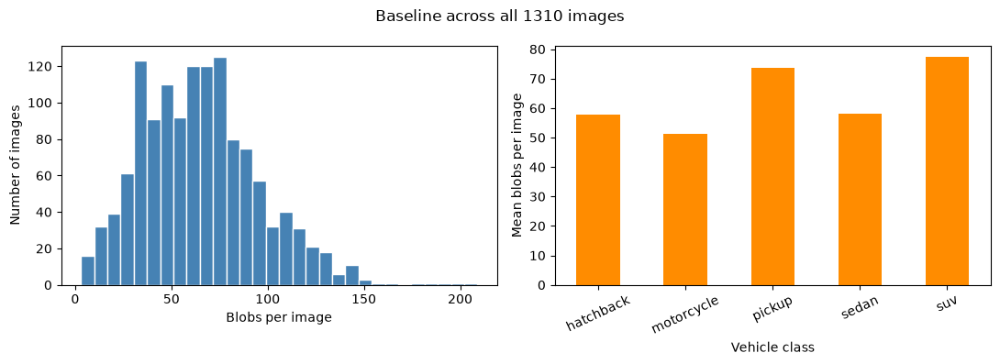

34251

In [15]:
summary_rows, detail_frames = [], []
for image_id, blobs in baseline_results.items():
    record = info_by_id[image_id]
    summary_rows.append(dict(image=image_id, n_blobs=len(blobs),
                             bright=int((blobs.polarity == "bright").sum()),
                             dark=int((blobs.polarity == "dark").sum()),
                             mean_radius_px=blobs.radius_px.mean(),
                             min_radius_px=blobs.radius_px.min(), max_radius_px=blobs.radius_px.max()))
    detail = blobs.copy()
    detail.insert(0, "blob_id", np.arange(1, len(detail) + 1))
    detail.insert(0, "image", image_id)
    # Pixel-center mapping for the resized, EXIF-oriented original.
    detail["original_x_px"] = (detail.x_px + 0.5) / record["scale_x"] - 0.5
    detail["original_y_px"] = (detail.y_px + 0.5) / record["scale_y"] - 0.5
    detail["original_radius_x_px"] = detail.radius_px / record["scale_x"]
    detail["original_radius_y_px"] = detail.radius_px / record["scale_y"]
    detail_frames.append(detail)
summary = pd.DataFrame(summary_rows)
blob_details = pd.concat(detail_frames, ignore_index=True)
print(f"Summary covers {len(summary)} images; detail table contains {len(blob_details)} blobs.")
print("Preview: one summary row per display example; all image rows are exported to CSV.")
display(summary[summary.image.isin(display_ids)].round(2))
print("Preview: first 20 blob measurements; all measurements are exported to CSV.")
display(blob_details.head(20).round(3))
summary["vehicle_class"] = summary.image.map(lambda i: Path(i).parts[0])
class_summary = summary.groupby("vehicle_class").agg(
    images=("image", "size"), total_blobs=("n_blobs", "sum"),
    mean_blobs_per_image=("n_blobs", "mean"), median_blobs_per_image=("n_blobs", "median"),
    images_without_blobs=("n_blobs", lambda values: int((values == 0).sum()))
)
display(class_summary.round(2))
class_summary.to_csv(RESULT_DIR / "class_summary.csv")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(summary.n_blobs, bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Blobs per image")
axes[0].set_ylabel("Number of images")
class_summary.mean_blobs_per_image.plot.bar(ax=axes[1], color="darkorange", rot=25)
axes[1].set_ylabel("Mean blobs per image")
axes[1].set_xlabel("Vehicle class")
fig.suptitle(f"Baseline across all {len(image_ids)} images")
fig.tight_layout()
save_figure(fig, FIGURE_DIR / "04_dataset_statistics.png", dpi=150)
plt.show()
plt.close(fig)
summary.to_csv(RESULT_DIR / "baseline_summary.csv", index=False)
blob_details.to_csv(RESULT_DIR / "baseline_blobs.csv", index=False)
image_info.to_csv(RESULT_DIR / "image_preparation.csv", index=False)
(RESULT_DIR / "baseline_config.json").write_text(json.dumps(
    dict(parameters=BASELINE, max_side=MAX_SIDE, images=image_ids, display_images=display_ids), indent=2), encoding="utf-8")

## 4. Evaluate the effect of algorithm parameters

**Assignment point 4:** Evaluate and discuss how different parameters affect detection of different blobs.

### Controlled parameter experiments

Change one parameter relative to the baseline at a time, using every image in the dataset:

- **Threshold 0.075 / 0.225:** admit weaker contrast responses or retain only stronger responses.
- **Minimum sigma 7:** exclude small-scale features.
- **Maximum sigma 30:** allow larger regions. With 12 scales fixed, the intermediate sampled scales also
  change; the effect is not only an increased upper radius limit.
- **Overlap 0.2:** suppress overlapping candidates more aggressively.
- **Extra smoothing sigma 2:** reduce fine texture before detection; this can also remove useful details.

The scale-range changes both alter the logarithmic sampling grid. Counts alone are not accuracy scores:
compare the actual circles as well as their number and average size.

Parameter experiments: 100/1310 images (22.8 s)
Parameter experiments: 200/1310 images (46.0 s)
Parameter experiments: 300/1310 images (63.4 s)
Parameter experiments: 400/1310 images (75.7 s)
Parameter experiments: 500/1310 images (87.3 s)
Parameter experiments: 600/1310 images (99.5 s)
Parameter experiments: 700/1310 images (112.5 s)
Parameter experiments: 800/1310 images (124.6 s)
Parameter experiments: 900/1310 images (138.1 s)
Parameter experiments: 1000/1310 images (150.3 s)
Parameter experiments: 1100/1310 images (165.2 s)
Parameter experiments: 1200/1310 images (180.2 s)
Parameter experiments: 1300/1310 images (201.3 s)
Parameter experiments: 1310/1310 images (204.7 s)
Counts cover all 1310 images; displaying the fixed examples only.


setting,baseline,lower threshold,higher threshold,larger minimum,larger maximum,stricter overlap,extra smoothing
image,,,,,,,
hatchback/PIC_0.jpg,33,63,9,12,32,31,15
hatchback/PIC_1.jpg,85,229,27,29,81,76,45
motorcycle/PIC_0.jpg,83,265,20,32,81,78,35
motorcycle/PIC_10.jpg,19,44,6,5,19,18,12
pickup/PIC_0.jpg,110,184,33,38,109,101,61
pickup/PIC_1.jpg,106,191,36,39,104,100,58
sedan/PIC_0.jpg,27,86,7,13,26,25,16
sedan/PIC_1.jpg,70,249,10,36,69,64,39
suv/PIC_0.jpg,107,312,38,40,113,97,49


,images,total_blobs,mean_radius_px
setting,,,
baseline,1310,85074,7.40
lower threshold,1310,198896,6.88
higher threshold,1310,25854,7.86
larger minimum,1310,35726,11.93
larger maximum,1310,84213,7.60
stricter overlap,1310,77302,7.36
extra smoothing,1310,44825,9.42


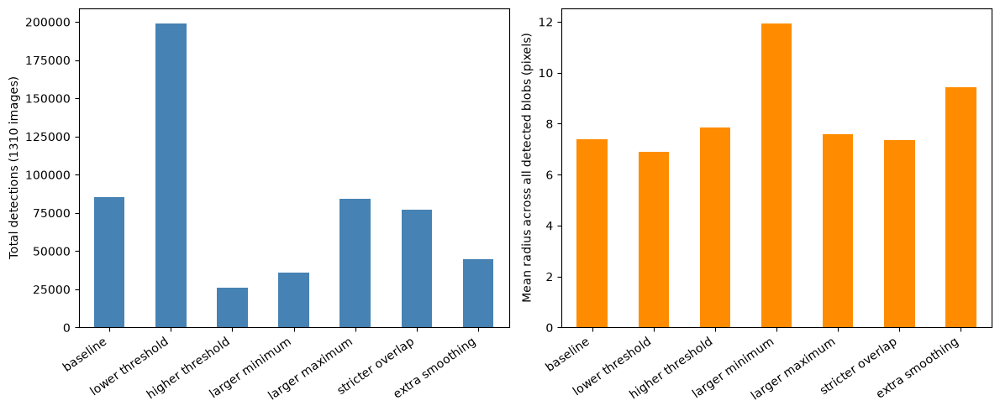

In [16]:
CONFIGS = {
    "baseline": BASELINE,
    "lower threshold": {**BASELINE, "threshold": 0.075},
    "higher threshold": {**BASELINE, "threshold": 0.225},
    "larger minimum": {**BASELINE, "min_sigma": 7.0},
    "larger maximum": {**BASELINE, "max_sigma": 30.0},
    "stricter overlap": {**BASELINE, "overlap": 0.2},
    "extra smoothing": {**BASELINE, "pre_smooth": 2.0},
}

def evaluate_parameters(image_id):
    record = records.get(image_id)
    if record is None:
        record = load_image(image_id)
    response_cache = {}  # Reuse responses for this image only; release them after this worker returns.
    rows, example_results = [], {}
    for name, config in CONFIGS.items():
        blobs = baseline_results[image_id] if name == "baseline" else detect_blobs(
            record["gray"], **config, response_cache=response_cache)
        rows.append(dict(setting=name, image=image_id, n_blobs=len(blobs),
                         mean_radius_px=blobs.radius_px.mean()))
        if image_id in display_ids:
            example_results[name] = blobs
    return rows, image_id, example_results

experiment_rows = []
experiment_results = {name: {} for name in CONFIGS}
started = time.perf_counter()
with ThreadPoolExecutor(max_workers=WORKERS) as pool:
    for done, (rows, image_id, examples) in enumerate(pool.map(evaluate_parameters, image_ids), start=1):
        experiment_rows.extend(rows)
        for name, blobs in examples.items():
            experiment_results[name][image_id] = blobs
        if done % 100 == 0 or done == len(image_ids):
            print(f"Parameter experiments: {done}/{len(image_ids)} images ({time.perf_counter() - started:.1f} s)", flush=True)
experiments = pd.DataFrame(experiment_rows)
assert len(experiments) == len(image_ids) * len(CONFIGS)
assert experiments.groupby("setting").image.nunique().eq(len(image_ids)).all()
counts = experiments.pivot(index="image", columns="setting", values="n_blobs").reindex(columns=CONFIGS)
print(f"Counts cover all {len(counts)} images; displaying the fixed examples only.")
display(counts.loc[display_ids])
aggregate_rows = []
for name in CONFIGS:
    rows = experiments[experiments.setting == name]
    total = int(rows.n_blobs.sum())
    mean_radius = (rows.mean_radius_px.fillna(0) * rows.n_blobs).sum() / total if total else np.nan
    aggregate_rows.append(dict(setting=name, images=len(rows), total_blobs=total, mean_radius_px=mean_radius))
aggregate = pd.DataFrame(aggregate_rows).set_index("setting")
display(aggregate.round(2))
experiments.to_csv(RESULT_DIR / "parameter_experiments.csv", index=False)
aggregate.to_csv(RESULT_DIR / "parameter_aggregate.csv")
(RESULT_DIR / "experiment_configs.json").write_text(json.dumps(CONFIGS, indent=2), encoding="utf-8")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
aggregate.total_blobs.plot.bar(ax=axes[0], color="steelblue", rot=35)
aggregate.mean_radius_px.plot.bar(ax=axes[1], color="darkorange", rot=35)
axes[0].set_ylabel(f"Total detections ({len(image_ids)} images)")
axes[1].set_ylabel("Mean radius across all detected blobs (pixels)")
for ax in axes:
    ax.set_xlabel("")
    plt.setp(ax.get_xticklabels(), ha="right")
fig.tight_layout()
save_figure(fig, FIGURE_DIR / "03_parameter_summary.png", dpi=150)
plt.show()
plt.close(fig)

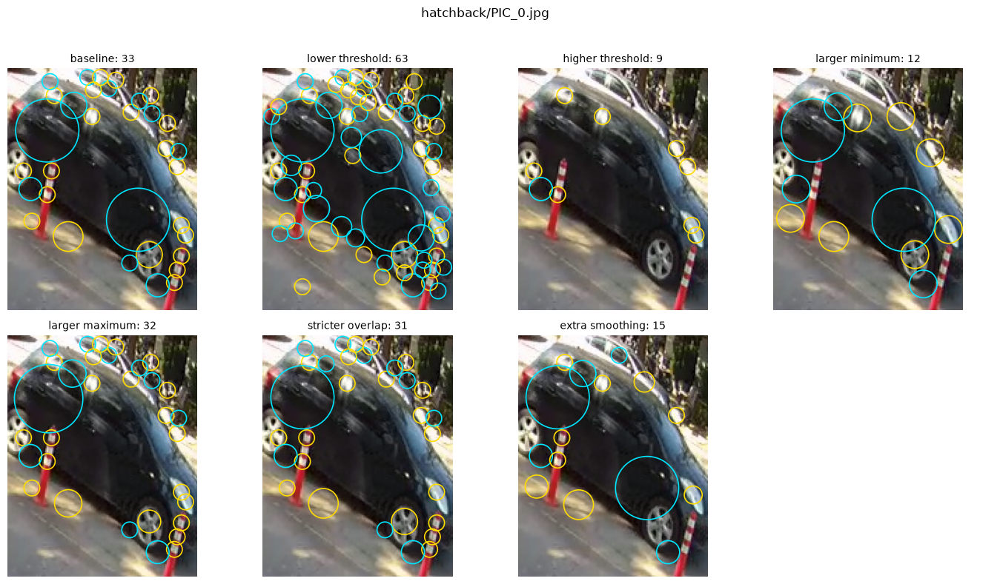

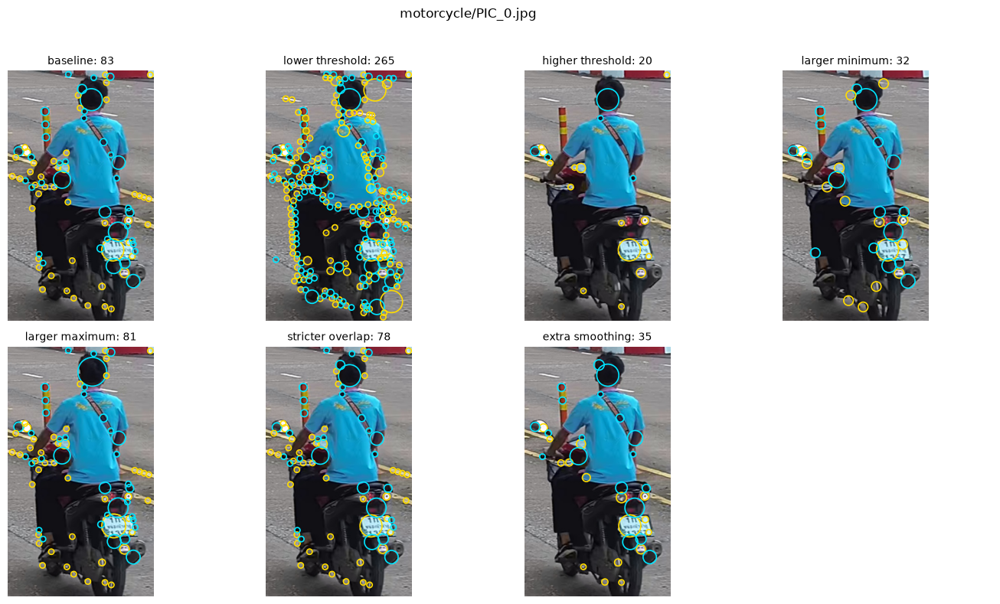

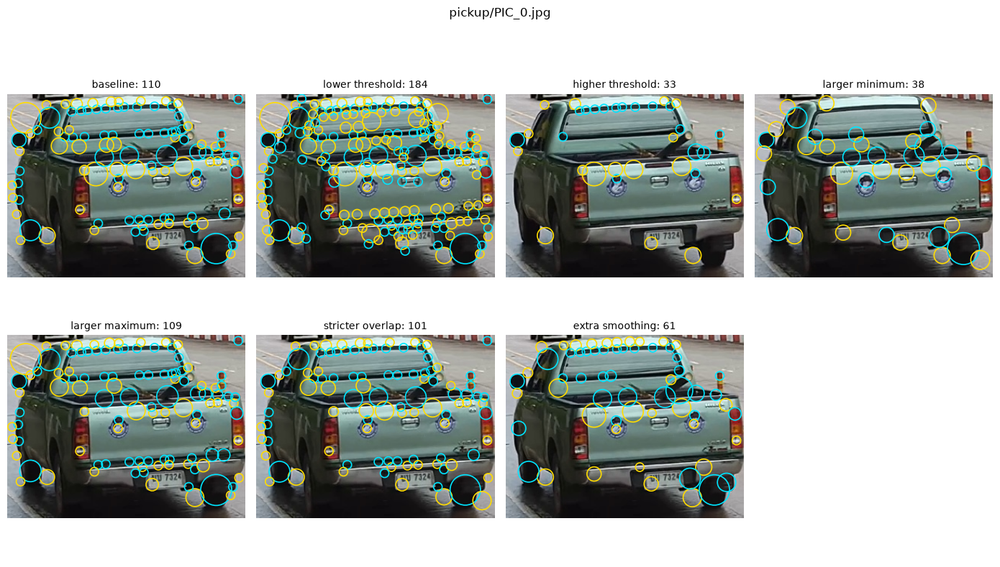

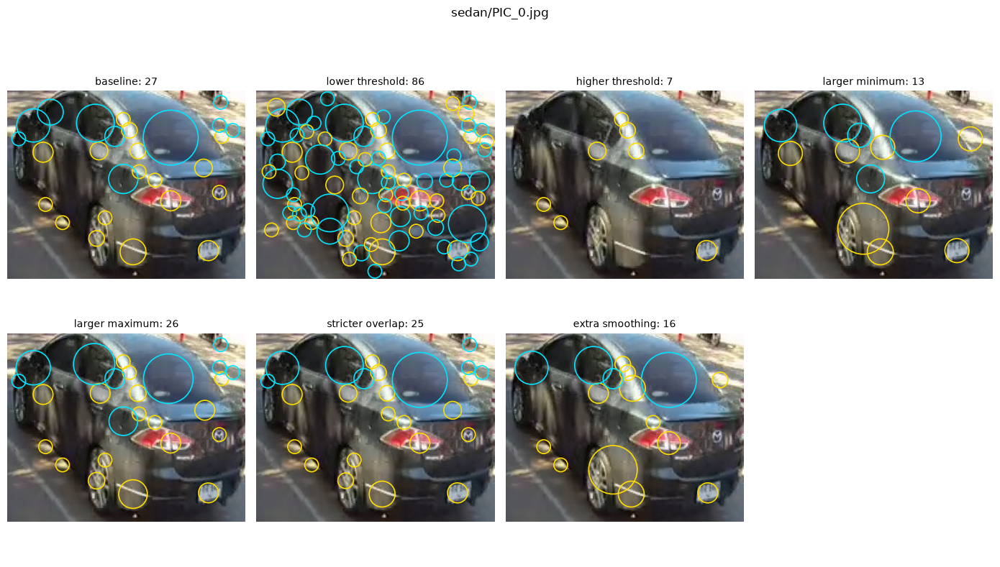

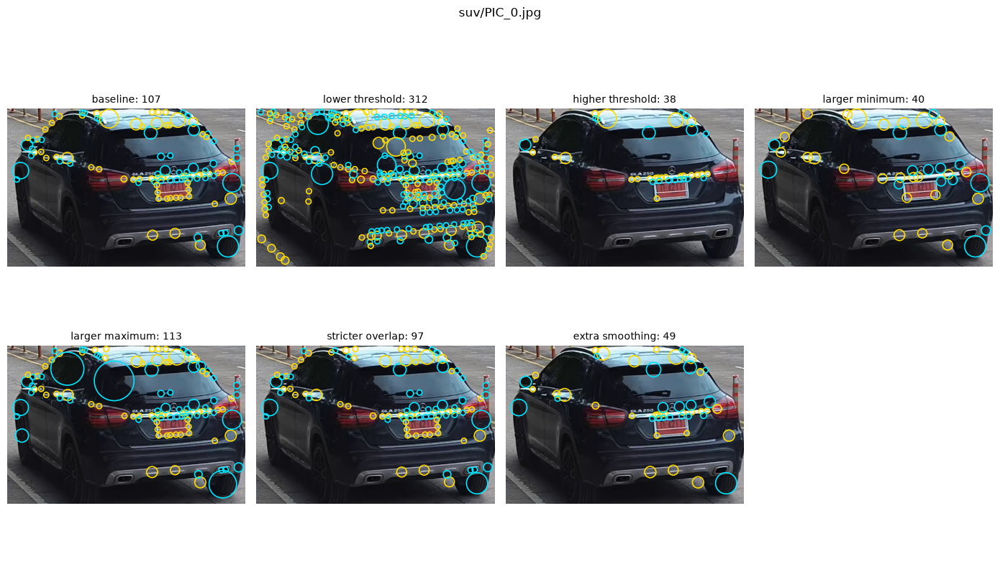

In [17]:
# The first image in each class: same examples for every setting, not cherry-picked by results.
example_ids = list(dict.fromkeys(image_id.split("/")[0] for image_id in display_ids))
example_ids = [next(i for i in display_ids if i.startswith(label + "/")) for label in example_ids]
for image_id in example_ids:
    fig, axes = plt.subplots(2, 4, figsize=(14, 8))
    for ax, name in zip(axes.flat, CONFIGS):
        blobs = experiment_results[name][image_id]
        draw_blobs(ax, records[image_id], blobs, f"{name}: {len(blobs)}")
    axes.flat[-1].axis("off")
    fig.suptitle(image_id)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    save_figure(fig, FIGURE_DIR / ("parameters_" + image_id.replace("/", "_").rsplit(".", 1)[0] + ".png"), dpi=140)
    plt.show()
    plt.close(fig)

### Results and discussion

The following numerical summary is generated from the current run, so it stays consistent if images
or parameters change. The numerical analysis covers the whole dataset; visual observations concern the named display examples.

In [18]:
baseline_total = int(aggregate.loc["baseline", "total_blobs"])
lines = [f"Baseline: **{baseline_total} blobs** across {len(image_ids)} images, with a mean estimated radius "
         f"of **{aggregate.loc['baseline', 'mean_radius_px']:.2f} pixels**."]
for name in list(CONFIGS)[1:]:
    row = aggregate.loc[name]
    lines.append(f"- {name.capitalize()}: **{int(row.total_blobs)} blobs** "
                 f"({int(row.total_blobs) - baseline_total:+d} relative to baseline); "
                 f"mean radius **{row.mean_radius_px:.2f} px**.")
display(Markdown("\n\n".join(lines)))

Baseline: **85074 blobs** across 1310 images, with a mean estimated radius of **7.40 pixels**.

- Lower threshold: **198896 blobs** (+113822 relative to baseline); mean radius **6.88 px**.

- Higher threshold: **25854 blobs** (-59220 relative to baseline); mean radius **7.86 px**.

- Larger minimum: **35726 blobs** (-49348 relative to baseline); mean radius **11.93 px**.

- Larger maximum: **84213 blobs** (-861 relative to baseline); mean radius **7.60 px**.

- Stricter overlap: **77302 blobs** (-7772 relative to baseline); mean radius **7.36 px**.

- Extra smoothing: **44825 blobs** (-40249 relative to baseline); mean radius **9.42 px**.

### Dataset-wide findings

The executed baseline processes all 1,310 images and detects 85,074 blobs, with a blob-weighted mean
radius of 7.40 processed pixels. Per-image counts range from 3 to 209. All seven settings cover all
1,310 images, producing 9,170 per-image/setting measurements. The lower threshold yields 198,896
blobs and the higher threshold 25,854. Larger minimum sigma yields 35,726 with mean radius 11.93;
extra smoothing yields 44,825 with mean radius 9.42. These patterns extend beyond the display examples.

Class-wise mean counts are approximately 57.7 (hatchback), 51.3 (motorcycle), 73.5 (pickup), 58.2
(sedan), and 77.3 (SUV). These descriptive differences reflect image composition, contrast, resolution,
and visible detail as well as vehicle appearance; they do not show that vehicle class causes a
particular blob count or that one class is detected more accurately. Per-image means avoid confusing
larger classes with more detailed images.

### Visual findings on display examples

The fixed display examples illustrate what the algorithm responds to: wheel regions, contrasting
window/body patches, road highlights, posts, trim, badges, number plates, clothing, and rider features.
These observations describe those named examples; the tables and aggregate plots cover every image.
LoG can respond along edges as well as at compact contrast features, so a blob does not automatically
represent a complete vehicle or an isolated circular object.

### Interpretation of parameter effects

The generated summary above reports the measured dataset-wide changes. Lower thresholds admit weaker
responses; raising the minimum sigma excludes small-scale features. Extra smoothing can remove fine
detail while preserving broader contrast. Increasing maximum sigma also changes the 12-point sampling
grid, and overlap/border rules influence the surviving detections, so counts need not increase.
A stricter overlap limit suppresses competing responses but may discard nearby distinct features.
Interpret these effects using both the full-dataset statistics and example overlays; counts alone are
not detection accuracy.

### Suitability and limitations

Every dataset image is processed, with per-image counts and numbered overlays plus per-blob measurements.
This resolves the earlier restriction to ten images. However, full coverage does not supply ground-truth
blob annotations. Baseline parameters were originally chosen on the display sample for readability;
their application to the rest of the dataset is not independent accuracy validation. Vehicle labels
cannot establish correct blob locations, and there is no confirmed optimal parameter setting.

The detector represents features with circular scale estimates, retains both contrast polarities, and
excludes circles crossing the frame. Illumination, perspective, occlusion, clutter, resolution, and the
scale-range endpoints still affect results. The contour notebook currently compares the shared display
examples only; its scope must be stated separately from this full-dataset blob analysis.

## References and reproducibility (supporting material)

- [SciPy Gaussian Laplacian](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.gaussian_laplace.html): Gaussian second derivatives.
- [SciPy maximum filter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.maximum_filter.html): neighborhood maximum operation.
- [scikit-image blob detection example](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_blob.html): LoG background and the approximate 2D radius convention. We implement the detector explicitly rather than calling `blob_log`.

This notebook is deterministic: the manifest and parameter values are fixed and no random sampling is used.
CSV files include all baseline detections and per-image statistics, and every parameter setting is
evaluated on every image. Original-resolution numbered overlays are under `results/.../overlays/`.
Tracked report figures show the fixed display examples and full-dataset aggregates. Image arrays are
loaded per worker rather than retaining every grayscale image in memory. LoG response caching is
restricted to parameter variants of the same image; vectorized overlap preserves the suppression rule.